In [1]:
import pyrealsense2 as rs
import numpy as np
import cv2

Saved: Data/camera/camerapose16.png


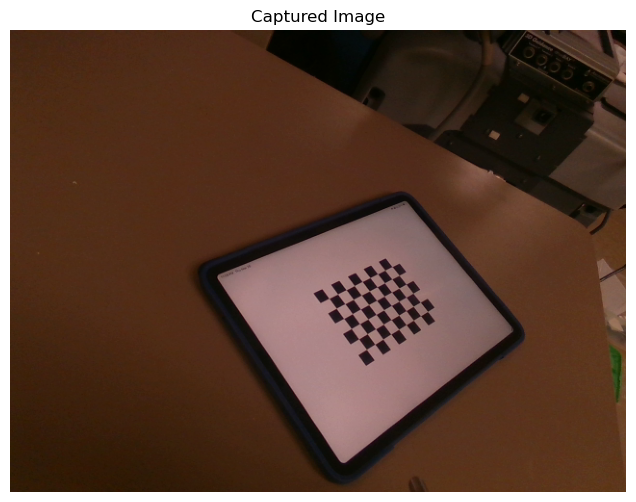

In [25]:
import os
pipeline = rs.pipeline()
config = rs.config()
config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)

pipeline.start(config)
try:
    # Small warmup for stable exposure
    for _ in range(10):
        pipeline.wait_for_frames()

    frames = pipeline.wait_for_frames()
    color_frame = frames.get_color_frame()
    if not color_frame:
        raise RuntimeError("No color frame received")

    color_image = np.asanyarray(color_frame.get_data())
    output_dir = os.path.join("Data", "camera")
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, "camerapose16.png")
    cv2.imwrite(output_path, color_image)
    print(f"Saved: {output_path}")

    # Show captured image in notebook
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
    plt.title("Captured Image")
    plt.axis("off")
    plt.show()
finally:
    pipeline.stop()